---
# COSC2753 | Machine Learning

## Task 2 — Member 2: Season Classification
---

# 1. Introduction

This notebook contains the complete season-classification experiment. Season can be subjective and weakly visible, so evaluation emphasizes macro F1, calibration, article-type confounding, and representative failures rather than accuracy alone.

# 2. Library Imports and Setup

In [1]:
from copy import deepcopy
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from skimage.feature import hog
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame
seed_everything(SEED); torch.manual_seed(SEED)
DEVICE = select_torch_device()
DEVICE

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

# 3. Frozen Data and Season EDA

In [2]:
TARGET = 'season'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
pd.DataFrame({
    'train': train_df[TARGET].value_counts(),
    'validation': validation_df[TARGET].value_counts(),
    'test': test_df[TARGET].value_counts(),
}).fillna(0).astype(int)

,train,validation,test
season,,,
Summer,13352,2918,2865
Fall,7363,1598,1551
Winter,5244,1083,1051
Spring,1079,239,248


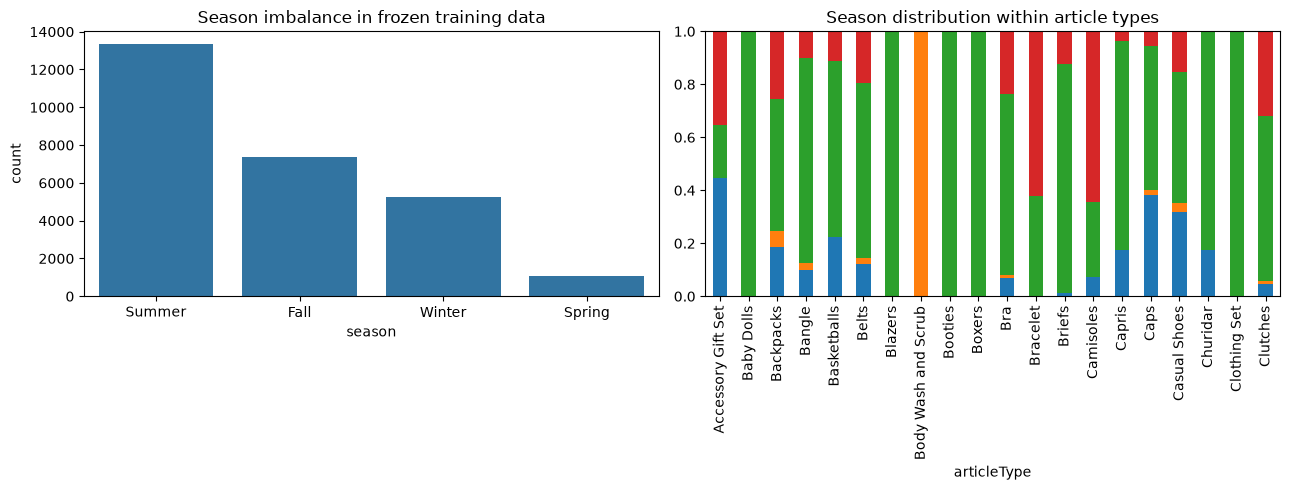

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=train_df, x=TARGET, order=train_df[TARGET].value_counts().index, ax=axes[0])
axes[0].set_title('Season imbalance in frozen training data')
pd.crosstab(train_df['articleType'], train_df[TARGET], normalize='index').head(20).plot(kind='bar', stacked=True, ax=axes[1], legend=False)
axes[1].set_title('Season distribution within article types')
plt.tight_layout()

## 3.1 Observations

Discuss Summer dominance, Spring support, blank-label exclusion, and whether garment type may act as a shortcut. Confirm that all validation/test labels exist in training before continuing.

# 4. Majority Baseline

In [4]:
dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
{'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions), 'macro_f1': f1_score(validation_df[TARGET], dummy_predictions, average='macro', zero_division=0)}

{'accuracy': 0.499828708461802, 'macro_f1': 0.16662859753312015}

# 5. HOG + HSV Classical Baseline

In [5]:
def handcrafted_feature(path):
    with Image.open(path) as source:
        image = source.convert('RGB').resize((48, 64))
    array = np.asarray(image, dtype=np.float32) / 255.0
    shape = hog(array.mean(axis=2), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    hsv = np.asarray(image.convert('HSV'), dtype=np.float32) / 255.0
    colour = np.concatenate([np.histogram(hsv[..., channel], bins=8, range=(0, 1), density=True)[0] for channel in range(3)])
    return np.concatenate([shape, colour]).astype(np.float32)

train_features = np.vstack([handcrafted_feature(path) for path in train_df.image_path])
validation_features = np.vstack([handcrafted_feature(path) for path in validation_df.image_path])
linear_baseline = LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1).fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
{'accuracy': accuracy_score(validation_df[TARGET], linear_predictions), 'macro_f1': f1_score(validation_df[TARGET], linear_predictions, average='macro', zero_division=0)}

D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'accuracy': 0.6269270298047277, 'macro_f1': 0.5870297688968635}

# 6. Image Dataset and Augmentation

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(8, translate=(0.05, 0.05)), transforms.ColorJitter(0.12, 0.12),
    transforms.ToTensor(), transforms.Normalize(normalisation['mean'], normalisation['std']),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])

class FashionDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame, self.transform = frame.reset_index(drop=True), transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, label_to_index[row[TARGET]]

train_loader = DataLoader(FashionDataset(train_df, train_transform), 64, shuffle=True, num_workers=0)
validation_loader = DataLoader(FashionDataset(validation_df, evaluation_transform), 128, num_workers=0)
test_loader = DataLoader(FashionDataset(test_df, evaluation_transform), 128, num_workers=0)

# 7. Compact Residual CNN From Scratch

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(output_channels, output_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity() if input_channels == output_channels and stride == 1 else nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 1, stride, bias=False), nn.BatchNorm2d(output_channels),
        )
    def forward(self, inputs):
        residual = self.shortcut(inputs)
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        return self.relu(outputs + residual)

class CompactCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            ResidualBlock(3, 32), nn.MaxPool2d(2), ResidualBlock(32, 64), nn.MaxPool2d(2),
            ResidualBlock(64, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, inputs): return self.classifier(self.features(inputs))

model = CompactCNN(len(labels)).to(DEVICE)
sum(parameter.numel() for parameter in model.parameters())

298756

# 8. Weighted-Loss Training

In [8]:
# Run once with 'ordinary' and once with 'weighted', resetting the model and seed each time.
LOSS_MODE = 'weighted'
counts = train_df[TARGET].value_counts().reindex(labels).values
weights = torch.tensor(len(train_df) / (len(labels) * counts), dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=None if LOSS_MODE == 'ordinary' else weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    losses, truth, predictions = [], [], []
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(images); loss = criterion(logits, targets)
            if training: loss.backward(); optimizer.step()
        losses.append(loss.item() * len(targets)); truth.extend(targets.cpu().tolist()); predictions.extend(logits.argmax(1).cpu().tolist())
    return {'loss': sum(losses) / len(loader.dataset), 'accuracy': accuracy_score(truth, predictions), 'macro_f1': f1_score(truth, predictions, average='macro', zero_division=0)}

1 {'loss': 1.209261604921995, 'accuracy': 0.3490921548475505, 'macro_f1': 0.3517920879169738} 80.5s


2 {'loss': 1.1758906130677995, 'accuracy': 0.3595409386776293, 'macro_f1': 0.36533481148093166} 58.0s


3 {'loss': 1.0458911616085897, 'accuracy': 0.48132922233641656, 'macro_f1': 0.454451995933138} 57.6s


4 {'loss': 1.042976044697809, 'accuracy': 0.4561493662213087, 'macro_f1': 0.4321867032081296} 57.7s


5 {'loss': 1.111135257887244, 'accuracy': 0.42685851318944845, 'macro_f1': 0.40241657348251714} 57.8s


...

11 {'loss': 0.9058558756396884, 'accuracy': 0.5642343268242549, 'macro_f1': 0.5233572551103105} 58.6s


12 {'loss': 0.9504990750447084, 'accuracy': 0.5011990407673861, 'macro_f1': 0.49092964343518475} 58.1s


13 {'loss': 0.9021180206555625, 'accuracy': 0.5313463514902363, 'macro_f1': 0.5015863583338478} 58.9s


14 {'loss': 0.908998668244866, 'accuracy': 0.5693730729701952, 'macro_f1': 0.5281840970573443} 59.2s


15 {'loss': 0.8777161994058819, 'accuracy': 0.5950668036998972, 'macro_f1': 0.5508832022387007} 59.6s


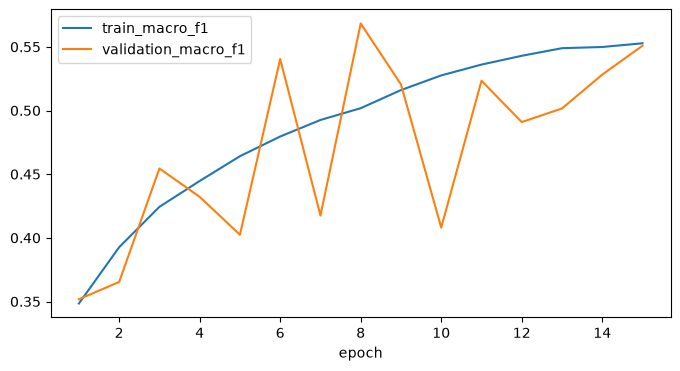

In [9]:
history, best_state, best_f1, patience = [], None, -1.0, 0
for epoch in range(1, 41):
    started = time.perf_counter()
    train_metrics, validation_metrics = run_epoch(train_loader, optimizer), run_epoch(validation_loader)
    history.append({'epoch': epoch, 'loss_mode': LOSS_MODE, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'validation_{k}': v for k, v in validation_metrics.items()}})
    print(epoch, validation_metrics, f'{time.perf_counter() - started:.1f}s')
    if validation_metrics['macro_f1'] > best_f1:
        best_f1, best_state, patience = validation_metrics['macro_f1'], deepcopy(model.state_dict()), 0
    else:
        patience += 1
        if patience >= 7: break
model.load_state_dict(best_state)
history = pd.DataFrame(history)
history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4)); plt.show()

## 7.1 Controlled comparison

Repeat training with ordinary cross-entropy under the same seed and architecture. Select the loss only from validation macro F1 and calibration; do not inspect internal-test metrics during this decision.

# 9. Final Evaluation

In [10]:
@torch.inference_mode()
def predict(loader):
    model.eval(); probabilities, truth = [], []
    for images, targets in loader:
        probabilities.append(model(images.to(DEVICE)).softmax(1).cpu().numpy()); truth.extend(targets.tolist())
    return np.vstack(probabilities), np.asarray(truth)

test_probabilities, test_truth = predict(test_loader)
test_predictions = test_probabilities.argmax(1)
test_metrics = {'accuracy': accuracy_score(test_truth, test_predictions), 'macro_f1': f1_score(test_truth, test_predictions, average='macro', zero_division=0)}
test_metrics

{'accuracy': 0.5706036745406824, 'macro_f1': 0.5696008292116448}

              precision    recall  f1-score   support

        Fall       0.60      0.44      0.50      1551
      Spring       0.79      0.48      0.60       248
      Summer       0.70      0.53      0.60      2865
      Winter       0.42      0.90      0.57      1051

    accuracy                           0.57      5715
   macro avg       0.63      0.59      0.57      5715
weighted avg       0.62      0.57      0.57      5715



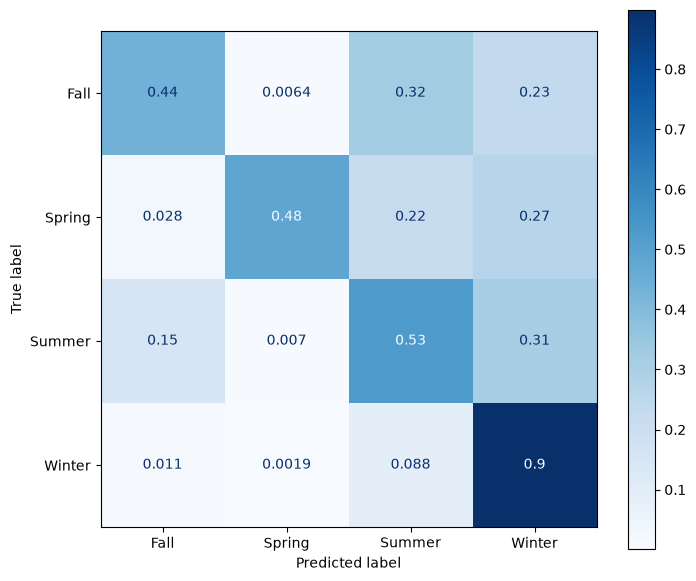

In [11]:
print(classification_report(
    test_truth, test_predictions, labels=np.arange(len(labels)), target_names=labels, zero_division=0,
))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    test_truth, test_predictions, labels=np.arange(len(labels)), display_labels=labels,
    normalize='true', ax=ax, cmap='Blues',
)
plt.show()

## 8.1 Calibration and failure analysis

In [12]:
confidence = test_probabilities.max(1)
correct = test_predictions == test_truth
calibration = pd.DataFrame({'confidence': confidence, 'correct': correct})
calibration['bin'] = pd.cut(calibration['confidence'], bins=np.linspace(0, 1, 11), include_lowest=True)
calibration.groupby('bin', observed=False).agg(mean_confidence=('confidence', 'mean'), accuracy=('correct', 'mean'), samples=('correct', 'size'))

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.288616,0.500000,6
"(0.3, 0.4]",0.369119,0.420213,376
"(0.4, 0.5]",0.452139,0.464820,1336
"(0.5, 0.6]",0.546550,0.523810,1218
"(0.6, 0.7]",0.649901,0.572885,981
"(0.7, 0.8]",0.748133,0.633286,709
"(0.8, 0.9]",0.849245,0.670498,522


Analyse high-confidence mistakes by article type and explain whether the model learned garment cues or seasonal priors. Include mild brightness/blur robustness, inference latency, checkpoint size, and the subjective nature of season labels.

# 10. Save the Selected Model

In [13]:
checkpoint_path = ROOT / 'models' / 'season_model.pt'
model = model.cpu()
torch.save({
    'target': TARGET, 'labels': labels, 'state_dict': model.state_dict(),
    'mean': normalisation['mean'], 'std': normalisation['std'], 'image_size': list(IMAGE_SIZE),
    'dropout': 0.2, 'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': best_f1,
    'test_metrics': test_metrics, 'seed': SEED,
}, checkpoint_path)
history.to_csv(ROOT / 'models' / 'season_history.csv', index=False)
checkpoint_path

WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/season_model.pt')

# 11. Final Prediction

Run `python scripts/task2_season_classification.py path/to/image.jpg` from the repository root to verify the saved artifact on CPU.

# 12. Ultimate Judgement and Conclusion

Replace this prompt with the real comparison among majority, HOG+HSV, ordinary-loss residual CNN, and weighted residual CNN; include class-specific findings, calibration, confounding evidence, limitations, and responsible interpretation of image-based season prediction.